# Validation Analysis: AP / PR Curves and Locator Threshold Sweep

Post-inference evaluation on the labeled validation sample for Germany. The notebook has two parts:

**Part A — AP & PR curves.** Computes Average Precision on the same labeled validation set for each ranking (prior alone using only priors probabilities, MLP alone using only mlps probabilities), then plots the precision-recall curves. AP depends only on the *order* of the scores; sklearn's `average_precision_score` uses the non-interpolated form (area under the PR curve).

**Part B — Locator threshold sweep.** Sweeps the classification threshold on `locators.pred_prob` from its minimum upward in steps of 0.01. At each threshold `t`, keeping only locator cells with `pred_prob >= t`:

1. **Precision** = TP / (TP + FP), where TP and FP are the counts of labelled validation polygons that intersect at least one retained locator.
2. **Detections** = count of prior polygons intersecting at least one retained locator.
3. **Estimated true positives** = precision × detections.
4. **Estimated est_tp_pct**  = estimated true positives / estimated total facilities.
5. **F1** = harmonic mean of precision and estimated est_tp_pct.

NPP = Estimated TPs - Estimated FPs is reported alongside as a second selection criterion, which gives a sense of the overall "pie".

## 1. Imports and Config

In [1]:
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, precision_recall_curve

warnings.filterwarnings("ignore")

# --- Paths ---------------------------------------------------------------
DATA      = Path("/Users/muhammadabdul/Desktop/work/climate_trace/germany_consolidated/data")
INFERENCE = Path("/Users/muhammadabdul/Desktop/work/climate_trace/germany_consolidated/inference")

VAL_RAW    = DATA / 'val' / "rs_val_priors_germany.gpkg"          # Validated sample: labels only, no model score.
PRIORS     = DATA / "priors_germany.gpkg"                 # Full prior set.
PREDS_FULL = INFERENCE / "stride_16/germany/predictions.shp"   # Raw scored grid, unthresholded. Part A.
LOCATORS   = INFERENCE / "post/germany/locators.shp"      # Post-processed / thresholded. Part B.
VAL_OUT    = DATA / 'val' / "rs_val_priors_germany_scored.gpkg"   # Written by A.0, read by Part A.

# --- Column names --------------------------------------------------------
LABEL_COL = "int_class"                  # Validation label: 1 = TP, 0 = FP.
PRIOR_COL = "confidence"                 # Stage 1 (prior) confidence score.
mlp_COL   = "confidence_mlp"             # Stage 2 score, built by the join in A.0.
PRED_COL  = "pred_prob"                  # Score field on the prediction layer.

# --- Join / sweep behaviour ---------------------------------------------
PREDICATE = "intersects"                 # Spatial predicate for the score join.
UNMATCHED = "zero"                       # Priors with no overlapping prediction cell:
                                         #   "zero" -> score 0 (model returned nothing there)
                                         #   "drop" -> exclude from AP/PR
                                         #   "nan"  -> keep NaN (breaks sklearn)
STEP      = 0.01                         # Threshold sweep step size.


## Part A — AP & PR Curves

### A.0 Attach the Stage-2 Score

For each validated prior, take the maximum `pred_prob` over every prediction cell it intersects. One
output row per prior, NaN where nothing intersects.

Two points to watch:

- **CRS.** `gpd.sjoin` does not reproject, and a CRS mismatch is a silent zero-match rather than an
  error, so both frames are pushed to the prediction CRS before the join.
- **Layer choice.** AP is a ranking metric, so this must run against the *unthresholded* grid
  (`PREDS_FULL`). Joining against the post-processed locators instead collapses every prior below the
  post-processing cutoff into a single tie at 0 and deflates AP. The guard below catches that case.
- **Unmatched priors.** `UNMATCHED` sets the policy. `"zero"` is right when the grid covers the full
  AOI (no overlapping cell genuinely means the model scored it lowest); `"drop"` is right if coverage
  is partial, in which case a missing cell is a gap rather than a negative.


In [2]:
def summarize_by_location(
    target: gpd.GeoDataFrame,
    source: gpd.GeoDataFrame,
    field: str,
    stats=("max",),
    predicate: str = "intersects",
    out_names: dict | None = None,
) -> gpd.GeoDataFrame:
    """Aggregate `field` from `source` onto each `target` feature by spatial relation.

    One row per `target` feature, with `field` aggregated over every source feature satisfying
    `predicate`. Targets with no match get NaN. `source` is reprojected to the target CRS first.
    `out_names` renames outputs, e.g. {"max": "confidence_mlp"}.
    """
    if target.crs is not None and source.crs is not None and source.crs != target.crs:
        source = source.to_crs(target.crs)

    stats     = tuple(stats)
    out_names = out_names or {}
    key       = "__tgt_idx__"

    # Positional key, so a non-unique or non-range index on `target` cannot scramble the alignment.
    t = target[["geometry"]].copy()
    t[key] = np.arange(len(t))

    joined = gpd.sjoin(t, source[["geometry", field]], how="inner", predicate=predicate)
    agg    = joined.groupby(key)[field].agg(list(stats))
    if isinstance(agg, pd.Series):                 # single stat -> Series
        agg = agg.to_frame(stats[0])
    agg = agg.reindex(np.arange(len(target)))      # reinstate the unmatched rows as NaN

    out = target.copy()
    for s in stats:
        out[out_names.get(s, f"{field}_{s}")] = agg[s].to_numpy()
    return out


# --- Run the join --------------------------------------------------------
val_raw = gpd.read_file(VAL_RAW)
preds   = gpd.read_file(PREDS_FULL)

# The scored grid must be unthresholded: a floor well above zero means post-processing already
# dropped the low-probability cells, and everything under it would tie at 0 in the ranking.
lo = float(preds[PRED_COL].min())
if lo > 0.05:
    print(f"WARNING: {PREDS_FULL.name} looks thresholded (min {PRED_COL} = {lo:.3f}). "
          f"AP needs the raw grid; priors scoring under {lo:.2f} will tie at 0.")

val_sample = summarize_by_location(
    val_raw.to_crs(preds.crs),
    preds,
    field=PRED_COL,
    stats=("max",),
    predicate=PREDICATE,
    out_names={"max": mlp_COL},
)

n_unmatched = int(val_sample[mlp_COL].isna().sum())
print(f"joined {len(val_sample):,} validated priors against {len(preds):,} prediction cells")
print(f"unmatched (no intersecting cell): {n_unmatched:,}  ({n_unmatched / len(val_sample):.2%})")

if UNMATCHED == "zero":
    val_sample[mlp_COL] = val_sample[mlp_COL].fillna(0.0)
elif UNMATCHED == "drop":
    val_sample = val_sample[val_sample[mlp_COL].notna()].reset_index(drop=True)

val_sample.to_file(VAL_OUT, driver="GPKG")
print(f"wrote {VAL_OUT}")
val_sample[[c for c in ("fid", PRIOR_COL, LABEL_COL, "comments", mlp_COL) if c in val_sample]].head()


joined 1,457 validated priors against 2,913,200 prediction cells
unmatched (no intersecting cell): 0  (0.00%)
wrote /Users/muhammadabdul/Desktop/work/climate_trace/germany_consolidated/data/val/rs_val_priors_germany_scored.gpkg


,confidence,int_class,comments,confidence_mlp
0,0.978960,1,obvious,0.946240
1,0.933610,1,obvious,0.994578
2,0.976300,1,obvious,0.979939
3,0.947134,0,obvious,0.187029
4,0.982185,1,obvious,0.988395


### A.1 Build the Label and Score Arrays

Binary target and the two score arrays to be ranked, plus the base rate.


In [3]:
# `val_sample` comes straight from A.0. Re-read from disk instead if running Part A standalone:
# val_sample = gpd.read_file(VAL_OUT)

y     = val_sample[LABEL_COL].to_numpy(dtype=int)
prior = val_sample[PRIOR_COL].to_numpy(dtype=float)
mlp   = val_sample[mlp_COL].to_numpy(dtype=float)

# AP cannot rank NaN; fail loudly rather than silently mis-ordering the curve.
assert not np.isnan(mlp).any(), f"{np.isnan(mlp).sum()} NaN in {mlp_COL} — set UNMATCHED to 'zero' or 'drop'"

# Ties at the low end flatten the ranking and cost AP; worth knowing how many there are.
n_tied = int((mlp == mlp.min()).sum())
if n_tied > 1:
    print(f"{n_tied:,} priors tied at the minimum score ({mlp.min():.4f})")

# Base rate = fraction of positives; this is the AP of a random ranking.
n, n_pos = len(y), int(y.sum())
base_rate = n_pos / n
print(f"n={n}  TP={n_pos}  FP={n - n_pos}  base rate={base_rate:.4f}")


n=1457  TP=841  FP=616  base rate=0.5772


### A.2 AP for Each Ranking

Same points, same labels; only the ranking changes.

In [4]:
# Score arrays to compare. Each entry produces one AP value and one PR curve.
rankings = {
    "Prior alone":     prior,
    "MLP alone":       mlp,
}

# Print AP for each ranking, plus its lift over the random baseline.
print(f"{'Ranking':<20}{'AP':>8}{'AP - baseline':>16}")
for name, s in rankings.items():
    ap  = average_precision_score(y, s)
    print(f"{name:<20}{ap:>8.4f}{ap - base_rate:>16.4f}")

Ranking                   AP   AP - baseline
Prior alone           0.6296          0.0524
MLP alone             0.8577          0.2805


### A.3 Precision-Recall Curves

Plot the PR curve for each ranking on the same axes, with the random baseline for reference.

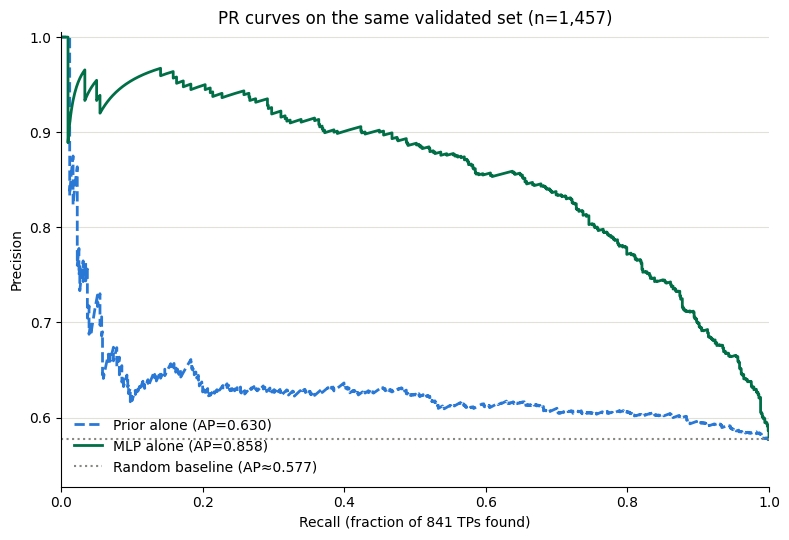

In [5]:
# One PR curve per ranking, with AP in the legend.
fig, ax = plt.subplots(figsize=(8, 5.5))
styles = [("#2a78d6", "--"), ("#006f48", "-"), ("#7f77dd", "-.")]

for (name, s), (color, ls) in zip(rankings.items(), styles):
    p_, r_, _ = precision_recall_curve(y, s)
    ap = average_precision_score(y, s)
    ax.plot(r_, p_, color=color, ls=ls, lw=2, label=f"{name} (AP={ap:.3f})")

# Random baseline: precision equals the base rate at any recall.
ax.axhline(base_rate, color="#898781", ls=":", lw=1.5,
           label=f"Random baseline (AP≈{base_rate:.3f})")

# Axis labels, limits, and styling.
ax.set_xlabel(f"Recall (fraction of {n_pos:,} TPs found)")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(max(0.0, base_rate - 0.05), 1.005)   # Zoom to the informative band.
ax.set_title(f"PR curves on the same validated set (n={n:,})")
ax.legend(loc="lower left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", lw=0.8)
plt.tight_layout()

# Uncomment to save the figure next to the input data.
# plt.savefig(f"{WD}/pr_curves.png", dpi=200)
plt.show()

## Part B — Locator Threshold Sweep

### B.1 Load Layers

Load the post-processed locators, the full prior set, and the scored validation sample; reproject
everything to the locator CRS and estimate the total facility count from the validation base rate.

Note this half runs against `LOCATORS`, not `PREDS_FULL`: the sweep evaluates the output that actually
ships, so a prior with no surviving locator cell should read as "not retained" rather than as a zero
score. `max_locator_prob` leaves those as NaN and the `np.nansum` comparisons below drop them.


In [6]:
locators = gpd.read_file(LOCATORS)
priors   = gpd.read_file(PRIORS).to_crs(locators.crs)
val      = val_sample.to_crs(locators.crs)          # already scored by A.0

# Estimated total facilities = validation base rate x number of priors.
TOTAL_FACILITIES = (val[LABEL_COL].sum() / val.shape[0]) * priors.shape[0]

# Split the validated sample into true and false positives.
tp = val[val[LABEL_COL] == 1]
fp = val[val[LABEL_COL] == 0]

print(f"locators: n={len(locators):,}  {PRED_COL} range "
      f"[{locators[PRED_COL].min():.3f}, {locators[PRED_COL].max():.3f}]")


locators: n=77,624  pred_prob range [0.450, 1.000]


### B.2 Max Locator Probability per Polygon

For each target polygon, take the maximum `pred_prob` over all intersecting locator cells. A polygon "survives" threshold `t` iff this max is >= `t`, so the sweep below reduces to comparing these arrays against each threshold.

In [7]:
def max_locator_prob(target: gpd.GeoDataFrame) -> np.ndarray:
    """Max pred_prob over intersecting locators, per target polygon (NaN if none)."""
    return summarize_by_location(
        target, locators, field=PRED_COL, stats=("max",), predicate=PREDICATE,
    )[f"{PRED_COL}_max"].to_numpy(dtype=float)


tp_max     = max_locator_prob(tp)
fp_max     = max_locator_prob(fp)
priors_max = max_locator_prob(priors)

# Priors with no surviving locator cell; they sit below the post-processing cutoff and are excluded
# from every threshold in the sweep.
print(f"validated priors with no locator: {int(np.isnan(np.r_[tp_max, fp_max]).sum()):,} / {len(val):,}")
print(f"all priors with no locator:       {int(np.isnan(priors_max).sum()):,} / {len(priors):,}")


validated priors with no locator: 361 / 1,457
all priors with no locator:       7,448 / 29,133


### B.3 Threshold Sweep

Sweep from the minimum locator probability upward in `STEP` increments, computing precision, detections, estimated TPs, estimated TPs percentage, F1, and NPP at each threshold.

In [ ]:
start = np.floor(locators.pred_prob.min() / STEP) * STEP
stop  = locators.pred_prob.max()
thresholds = np.round(np.arange(start, stop, STEP), 4)

rows = []
for t in thresholds:
    n_tp = int(np.nansum(tp_max >= t))
    n_fp = int(np.nansum(fp_max >= t))
    if n_tp + n_fp == 0:          # precision undefined, nothing left to score
        continue
    detections = int(np.nansum(priors_max >= t))

    precision = n_tp / (n_tp + n_fp)
    est_tp    = precision * detections
    est_tp_pct    = est_tp / TOTAL_FACILITIES
    f1        = 0.0 if (precision + est_tp_pct) == 0 else 2 * precision * est_tp_pct / (precision + est_tp_pct)
    npp       = detections * (2 * precision - 1)

    rows.append(
        dict(threshold=t, n_locators=int((locators.pred_prob >= t).sum()),
             tp=n_tp, fp=n_fp, precision=precision, detections=detections,
             est_tp=est_tp, est_tp_pct=est_tp_pct, f1=f1, npp=npp)
    )

results = pd.DataFrame(rows)

### B.4 Best Threshold

Report the thresholds that maximize F1.

In [ ]:
best_f1  = results.loc[results.f1.idxmax()]

print(f"Best F1  : threshold {best_f1.threshold:.3f}   "
      f"F1 {best_f1.f1:.4f}   precision {best_f1.precision:.4f}   base_line_precision {val[LABEL_COL].sum() / len(val):.4f}   est_tp_pct {best_f1.est_tp_pct:.4f}   "
      f"est TP {best_f1.est_tp:,.0f}   NPP {best_f1.npp:,.0f}")

BEST_THRESHOLD = float(best_f1.threshold)

Best F1  : threshold 0.660   F1 0.7965   precision 0.7644   base_line_precision 0.5772   est_tp_pct 0.8315   est TP 13,982   NPP 9,673


### B.5 Sweep Plot

F1, precision, and estimated TPs percentage against the classification threshold, with the best-F1 threshold marked.

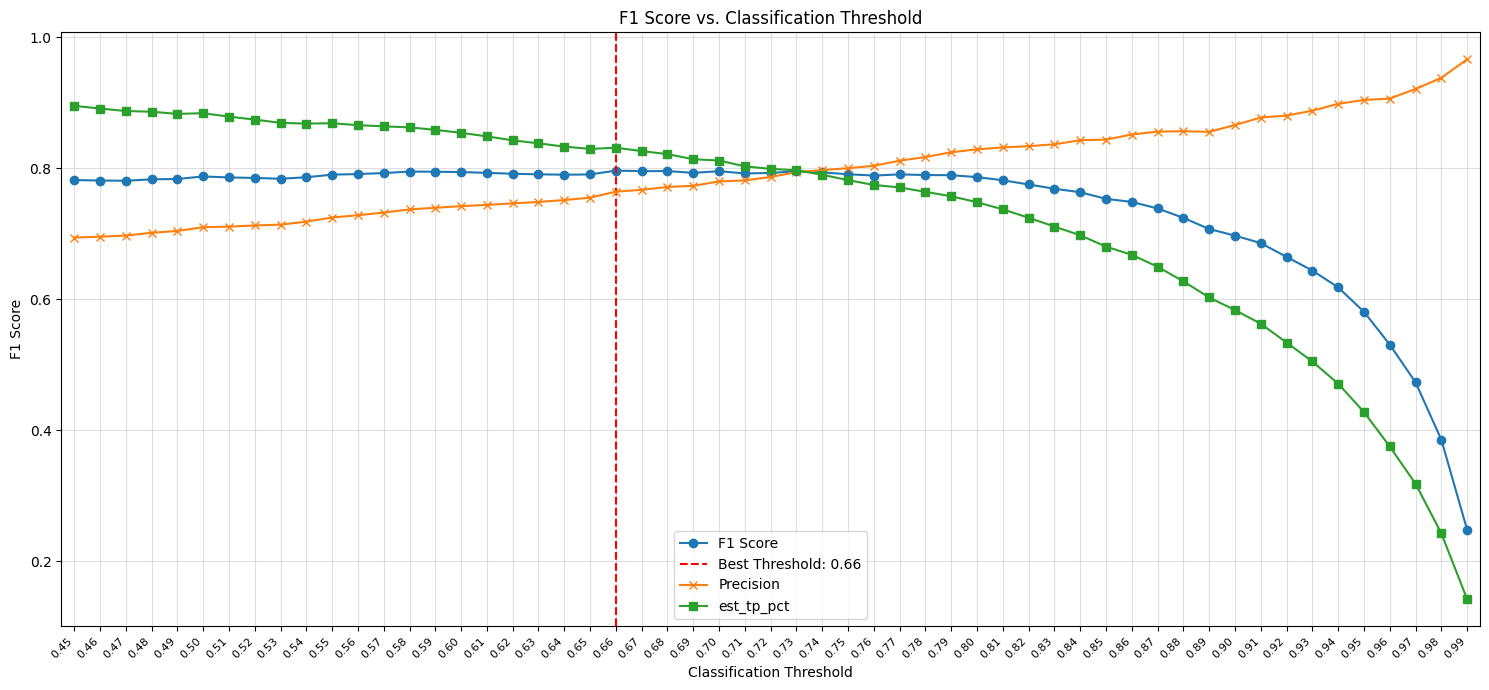

In [10]:
fig, ax = plt.subplots(figsize=(15, 7))

x = np.arange(len(results))
ax.plot(x, results.f1,        marker="o", color="tab:blue",   label="F1 Score")
ax.axvline(x[results.f1.idxmax()], color="red", linestyle="--",
           label=f"Best Threshold: {BEST_THRESHOLD:.2f}")
ax.plot(x, results.precision, marker="x", color="tab:orange", label="Precision")
ax.plot(x, results.est_tp_pct,    marker="s", color="tab:green",  label="est_tp_pct")

ax.set_xticks(x)
ax.set_xticklabels([f"{t:.2f}" for t in results.threshold], rotation=45, ha="right", fontsize=8)
ax.set_xlim(x[0] - 0.5, x[-1] + 0.5)
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("F1 Score")
ax.set_title("F1 Score vs. Classification Threshold")
ax.grid(True, alpha=0.4)
ax.legend(loc="lower center")

fig.tight_layout()
plt.show()

### B.6 Full Results Table

In [11]:
pd.set_option('display.max_rows', None)
results

,threshold,n_locators,tp,fp,precision,detections,est_tp,est_tp_pct,f1,npp
0,0.45,77624,761,335,0.694343,21685,15056.829380,0.895389,0.782153,8428.658759
1,0.46,76488,759,332,0.695692,21543,14987.293309,0.891254,0.781423,8431.586618
2,0.47,75325,758,329,0.697332,21402,14924.301748,0.887508,0.781010,8446.603496
3,0.48,74191,755,321,0.701673,21243,14905.636617,0.886398,0.783292,8568.273234
4,0.49,73097,753,316,0.704397,21082,14850.089804,0.883095,0.783688,8618.179607
5,0.50,72035,752,307,0.710104,20938,14868.154863,0.884169,0.787634,8798.309726
6,0.51,70939,748,304,0.711027,20786,14779.399240,0.878891,0.786097,8772.798479
7,0.52,69818,742,299,0.712776,20629,14703.859750,0.874399,0.785359,8778.719500
8,0.53,68774,739,296,0.714010,20476,14620.061836,0.869416,0.784087,8764.123671
9,0.54,67614,738,289,0.718598,20319,14601.189873,0.868294,0.786385,8883.379747
